In [1]:
import uproot
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import lightning as L
import seaborn as sns
import vector

In [2]:
# basic random seed
def seed_basic(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


# torch random seed
def seed_torch(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# basic + torch + lightning
def seed_everything(seed=42):
    seed_basic(seed)
    seed_torch(seed)
    L.seed_everything(seed)


seed_everything()

Seed set to 42


### Experiments

In [219]:
from scipy.stats import chisquare
def plot_cosine_true(test_data, name, bins = 100, alpha = 0.5):
    true_hist = np.histogram(Cos_lep_light_true, bins = bins)[0]
    fig, ax = plt.subplots(1, figsize = (8, 6))
    plt.hist(Cos_lep_light_true, bins=bins, alpha=1, label='true', histtype='step', linewidth = 2)
    plt.hist(Cos_lep_light_nophi_true, bins=bins, alpha=1, label='true_nophi', histtype='step', linewidth = 2)
    plt.title(r'$cos(\mu, d)_{TRF}$ reconstruction, DM, DELPHES level, ' + name)
    plt.legend()
    name = name.replace('$', '').replace('\\', '')
    plt.savefig(f"../plots/delphes/Cos_DM_{name}.pdf")
    plt.show()

In [268]:
file_sm = uproot.open("../data/SM_delphes_new.root")
df_SM = file_sm['Vars'].arrays(file_sm['Vars'].keys(), library="pd")

In [271]:
p_nu_x = np.array(df_SM['Px_NuGen'])
p_nu_y = np.array(df_SM['Py_NuGen'])
p_nu_z = np.array(df_SM['Pz_NuGen'])
p4nm_delp_gen = vector.arr({"px": p_nu_x, "py": p_nu_y, "pz": p_nu_z, "M": np.zeros_like(p_nu_x)})

pt_l = np.array(df_SM['Px_LepGen'])
eta_l = np.array(df_SM['Py_LepGen'])
phi_l = np.array(df_SM['Pz_LepGen'])
M_l = np.array(df_SM['E_LepGen'])
p4Mu_delp_gen = vector.arr({"px": pt_l, "py": eta_l, "pz": phi_l, "E": M_l})

pt_b = np.array(df_SM['Px_b1Gen'])
eta_b = np.array(df_SM['Py_b1Gen'])
phi_b = np.array(df_SM['Pz_b1Gen'])
M_b = np.array(df_SM['E_b1Gen'])
p4b1_delp_gen = vector.arr({"px": pt_b, "py": eta_b, "pz": phi_b, "E": M_b})

pt_b = np.array(df_SM['Px_b2Gen'])
eta_b = np.array(df_SM['Py_b2Gen'])
phi_b = np.array(df_SM['Pz_b2Gen'])
M_b = np.array(df_SM['E_b2Gen'])
p4b2_delp_gen = vector.arr({"px": pt_b, "py": eta_b, "pz": phi_b, "E": M_b})

pt_b = np.array(df_SM['Px_btopGen'])
eta_b = np.array(df_SM['Py_btopGen'])
phi_b = np.array(df_SM['Pz_btopGen'])
M_b = np.array(df_SM['E_btopGen'])
p4btop_delp_gen = vector.arr({"px": pt_b, "py": eta_b, "pz": phi_b, "E": M_b})

pt_q = np.array(df_SM['Px_J1Gen'])
eta_q = np.array(df_SM['Py_J1Gen'])
phi_q = np.array(df_SM['Pz_J1Gen'])
M_q = np.array(df_SM['E_J1Gen'])
p4j2_delp_gen = vector.arr({"px": pt_q, "py": eta_q, "pz": phi_q, "E": M_q})

p4W_delp_gen = p4Mu_delp_gen + p4nm_delp_gen

p4top2_delp_gen = p4W_delp_gen + p4b2_delp_gen
p4top1_delp_gen = p4W_delp_gen + p4b1_delp_gen

In [272]:
np.where(np.abs(p4top2_delp_gen.M - 173) < np.abs(p4top1_delp_gen.M - 173))[0].shape

(94930,)

In [276]:
p4b1_delp_gen = vector.MomentumNumpy4D(np.where(np.abs(p4top2_delp_gen.M - 172.5) < np.abs(p4top1_delp_gen.M - 172.5), p4b2_delp_gen, p4b1_delp_gen))

In [278]:
p4top_delp_gen = p4W_delp_gen + p4btop_delp_gen
p4b1_delp_gen = p4btop_delp_gen
np.where(np.abs(p4top2_delp_gen.M - 172.5) < np.abs(p4top_delp_gen.M - 172.5))[0].shape

(1,)

In [279]:
px_q = np.array(df_SM['Px_J1Gen'])
py_q = np.array(df_SM['Py_J1Gen'])
pz_q = np.array(df_SM['Pz_J1Gen'])
e_q = np.array(df_SM['E_J1Gen'])
p4j1_delp_gen = vector.arr({"px": px_q, "py": py_q, "pz": pz_q, "E": e_q})

px_q = np.array(df_SM['Px_J2Gen'])
py_q = np.array(df_SM['Py_J2Gen'])
pz_q = np.array(df_SM['Pz_J2Gen'])
e_q = np.array(df_SM['E_J2Gen'])
p4j2_delp_gen = vector.arr({"px": px_q, "py": py_q, "pz": pz_q, "E": e_q})

px_q = np.array(df_SM['Px_J3Gen'])
py_q = np.array(df_SM['Py_J3Gen'])
pz_q = np.array(df_SM['Pz_J3Gen'])
e_q = np.array(df_SM['E_J3Gen'])
p4j3_delp_gen = vector.arr({"px": px_q, "py": py_q, "pz": pz_q, "E": e_q})

In [280]:
p4j2_delp_gen = vector.MomentumNumpy4D(np.where(np.abs(p4j1_delp_gen.eta) > np.abs(p4j2_delp_gen.eta), p4j1_delp_gen, p4j2_delp_gen))

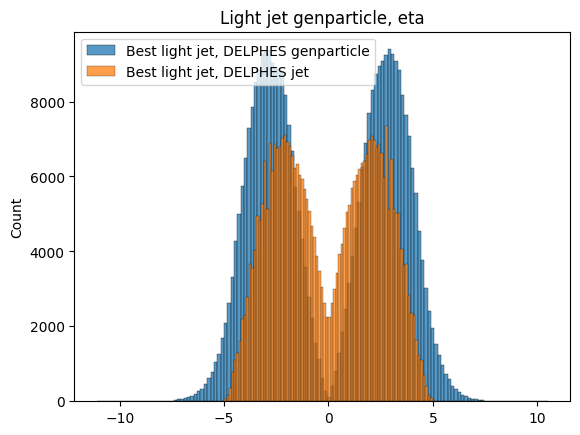

In [281]:
sns.histplot(p4j_eta_best.eta, label = 'Best light jet, DELPHES genparticle')
sns.histplot(p4j2_delp.eta, label = 'Best light jet, DELPHES jet')
plt.title('Light jet genparticle, eta')
plt.legend()
plt.show()

In [282]:
pt_l = np.array(df_SM['Pt_Lep'])
eta_l = np.array(df_SM['Eta_Lep'])
phi_l = np.array(df_SM['Phi_Lep'])
M = np.array(df_SM['E_Lep'])
p4Mu_delp = vector.arr({"pt": pt_l, "eta": eta_l, "phi": phi_l, "E": M})

pt_b = np.array(df_SM['Pt_BJ1'])
eta_b = np.array(df_SM['Eta_BJ1'])
phi_b = np.array(df_SM['Phi_BJ1'])
M = np.array(df_SM['E_BJ1'])
p4b1_delp = vector.arr({"pt": pt_b, "eta": eta_b, "phi": phi_b, "E": M})

# pt_b = np.array(df_SM['Pt_BJ2'])
# eta_b = np.array(df_SM['Eta_BJ2'])
# phi_b = np.array(df_SM['Phi_BJ2'])
# M = np.array(df_SM['M_BJ2'])
# p4b2_delp = vector.arr({"pt": pt_b, "eta": eta_b, "phi": phi_b, "M": M})

pt_q = np.array(df_SM['Pt_LJ'])
eta_q = np.array(df_SM['Eta_LJ'])
phi_q = np.array(df_SM['Phi_LJ'])
M = np.array(df_SM['E_LJ'])
p4j2_delp = vector.arr({"pt": pt_q, "eta": eta_q, "phi": phi_q, "E": M})

p4W_delp = p4Mu_delp + p4nm_delp_gen
p4top_delp = p4W_delp + p4b1_delp

In [283]:
from numpy import genfromtxt
passed_events = genfromtxt('delphes_events.txt', delimiter=' ')
passed_events = passed_events.astype(int)

In [284]:
file_sm = uproot.open("../data/SM.root")
df_SM = file_sm['LHE'].arrays(file_sm['LHE'].keys(), library="pd")
df_SM['M_phi'] = np.sqrt(df_SM['E_phi']**2 - (df_SM['p_phi_x']**2 + df_SM['p_phi_y']**2 + df_SM['p_phi_z']**2))

In [285]:
df_SM_passed = df_SM.iloc[passed_events]
df_SM_rejected = df_SM.iloc[~passed_events]

In [286]:
def build_4_vec(data):
    p_nu_x = np.array(data['p_nu_x'])
    p_nu_y = np.array(data['p_nu_y'])
    p_nu_z = np.array(data['p_nu_z'])
    p4nm_gen = vector.arr({"px": p_nu_x, "py": p_nu_y, "pz": p_nu_z, "M": np.zeros_like(p_nu_x)})
    
    #Lepton
    p_l_x = np.array(data['p_l_x'])
    p_l_y = np.array(data['p_l_y'])
    p_l_z = np.array(data['p_l_z'])
    E = np.sqrt(p_l_x**2 + p_l_y**2 + p_l_z**2)
    p4Mu_gen = vector.arr({"px": p_l_x, "py": p_l_y, "pz": p_l_z, "E": E})
    
    #b-quark
    p_b_x = np.array(data['p_b_x'])
    p_b_y = np.array(data['p_b_y'])
    p_b_z = np.array(data['p_b_z'])
    E = np.sqrt(p_b_x**2 + p_b_y**2 + p_b_z**2)
    p4j1_gen = vector.arr({"px": p_b_x, "py": p_b_y, "pz": p_b_z, "E": E})
    
    #light quark
    p_q_x = np.array(data['p_q_x'])
    p_q_y = np.array(data['p_q_y'])
    p_q_z = np.array(data['p_q_z'])
    E = np.sqrt(p_q_x**2 + p_q_y**2 + p_q_z**2)
    p4j2_gen = vector.arr({"px": p_q_x, "py": p_q_y, "pz": p_q_z, "E": E})


    return p4nm_gen, p4Mu_gen, p4j1_gen, p4j2_gen

In [287]:
p4nm_gen, p4Mu_gen, p4b1_gen, p4j2_gen = build_4_vec(df_SM)

In [288]:
p4W_gen = p4Mu_gen + p4nm_gen
p4top_gen = p4W_gen + p4b1_gen

In [289]:
boostedLepton_gen = p4Mu_gen.to_xyzt().boostCM_of_p4(-p4top_gen.to_xyzt())
boostedLJet_gen = p4j2_gen.to_xyzt().boostCM_of_p4(-p4top_gen.to_xyzt())
# Get the spatial components as 3D vectors
p3Lepton = boostedLepton_gen.to_beta3()
p3LJet = boostedLJet_gen.to_beta3()

# Calculate the cosine of the angle
Cos_lep_light_gen = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

In [290]:
boostedLepton_delp_gen = p4Mu_delp_gen.to_xyzt().boostCM_of_p4(-p4top_delp_gen.to_xyzt())
boostedLJet_delp_gen = p4j2_delp_gen.to_xyzt().boostCM_of_p4(-p4top_delp_gen.to_xyzt())
# Get the spatial components as 3D vectors
p3Lepton = boostedLepton_delp_gen.to_beta3()
p3LJet = boostedLJet_delp_gen.to_beta3()

# Calculate the cosine of the angle
Cos_lep_light_delp_gen = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

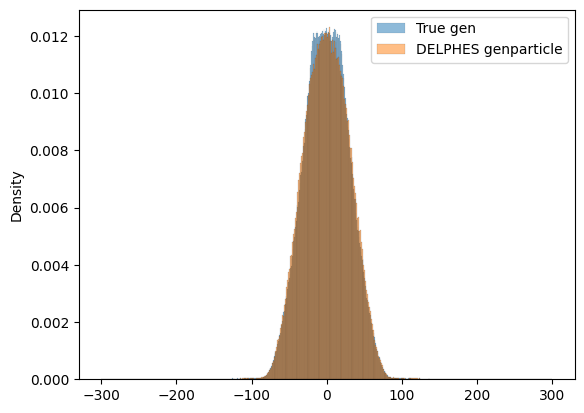

In [291]:
sns.histplot(boostedLepton_gen.pz, stat = 'density', binrange = [-300,300], label = "True gen", alpha = .5)
sns.histplot(boostedLepton_delp_gen.pz, stat = 'density', binrange = [-300,300], label = "DELPHES genparticle", alpha = .5)
plt.legend()

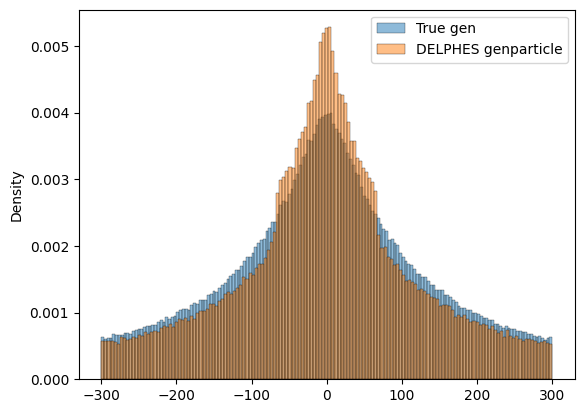

In [292]:
sns.histplot(boostedLJet_gen.pz, stat = 'density', binrange = [-300,300], label = "True gen", alpha = .5)
sns.histplot(boostedLJet_delp_gen.pz, stat = 'density', binrange = [-300,300], label = "DELPHES genparticle", alpha = .5)
plt.legend()

## Сравнение отбора

In [293]:
p4nm_passed, p4Mu_passed, p4b1_passed, p4j2_passed = build_4_vec(df_SM_passed)
p4W_passed = p4Mu_passed + p4nm_passed
p4top_passed = p4W_passed + p4b1_passed

In [294]:
p4nm_rejected, p4Mu_rejected, p4b1_rejected, p4j2_rejected = build_4_vec(df_SM_rejected)
p4W_rejected = p4Mu_rejected + p4nm_rejected
p4top_rejected = p4W_rejected + p4b1_rejected

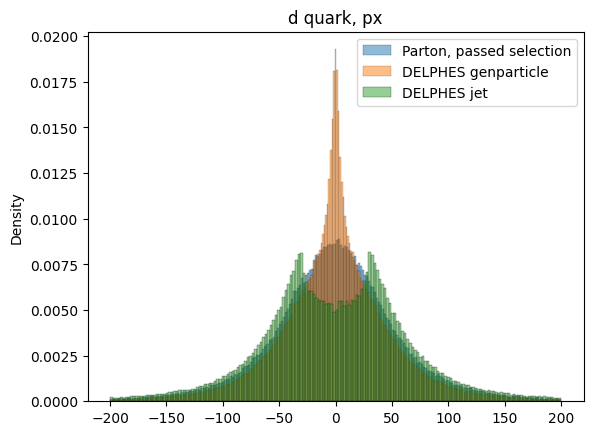

In [295]:
sns.histplot(p4j2_passed.px, stat = 'density', label = "Parton, passed selection", alpha = .5, binrange = [-200,200])
# sns.histplot(p4j1_rejected.px, stat = 'density', label = "Gen, rejected by selection", alpha = .5, binrange = [-100,100])
sns.histplot(p4j2_delp_gen.px, stat = 'density', label = "DELPHES genparticle", alpha = .5, binrange = [-200,200])
sns.histplot(p4j2_delp.px, stat = 'density', label = "DELPHES jet", alpha = .5, binrange = [-200,200])
plt.legend(loc = 'upper right')
plt.title('d quark, px')
plt.show()

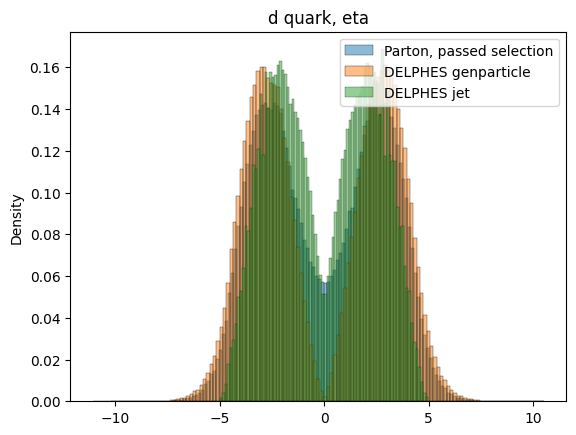

In [296]:
sns.histplot(p4j2_passed.eta, stat = 'density', label = "Parton, passed selection", alpha = .5)
# sns.histplot(p4j1_rejected.px, stat = 'density', label = "Gen, rejected by selection", alpha = .5, binrange = [-100,100])
sns.histplot(p4j2_delp_gen.eta, stat = 'density', label = "DELPHES genparticle", alpha = .5,)
sns.histplot(p4j2_delp.eta, stat = 'density', label = "DELPHES jet", alpha = .5)
plt.legend(loc = 'upper right')
plt.title('d quark, eta')
plt.show()

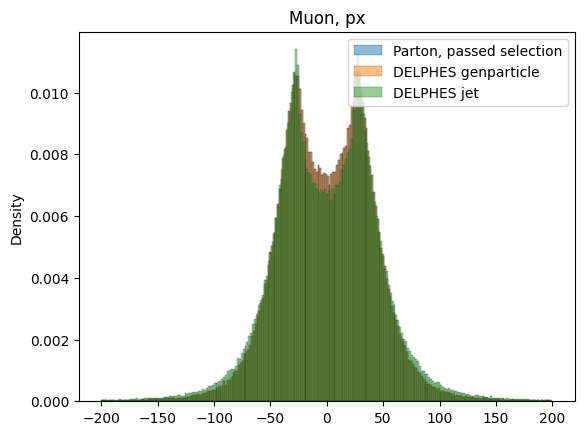

In [297]:
sns.histplot(p4Mu_passed.px, stat = 'density', label = "Parton, passed selection", alpha = .5, binrange = [-200,200])
# sns.histplot(p4j1_rejected.px, stat = 'density', label = "Gen, rejected by selection", alpha = .5, binrange = [-100,100])
sns.histplot(p4Mu_delp_gen.px, stat = 'density', label = "DELPHES genparticle", alpha = .5, binrange = [-200,200])
sns.histplot(p4Mu_delp.px, stat = 'density', label = "DELPHES jet", alpha = .5, binrange = [-200,200])
plt.legend(loc = 'upper right')
plt.title('Muon, px')
plt.show()

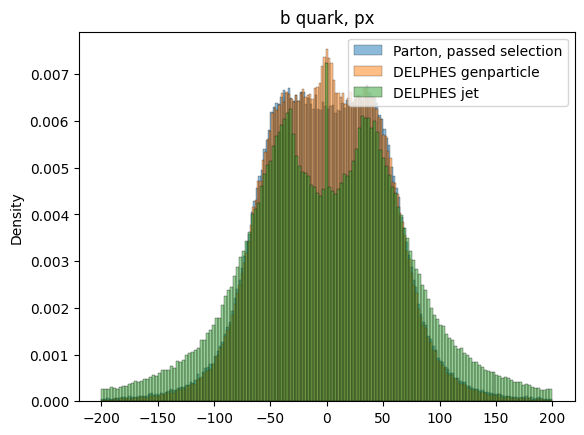

In [298]:
sns.histplot(p4b1_passed.px, stat = 'density', label = "Parton, passed selection", alpha = .5, binrange = [-200,200])
# sns.histplot(p4j1_rejected.px, stat = 'density', label = "Gen, rejected by selection", alpha = .5, binrange = [-100,100])
sns.histplot(p4b1_delp_gen.px, stat = 'density', label = "DELPHES genparticle", alpha = .5, binrange = [-200,200])
sns.histplot(p4b1_delp.px, stat = 'density', label = "DELPHES jet", alpha = .5, binrange = [-200,200])
plt.legend(loc = 'upper right')
plt.title('b quark, px')
plt.show()

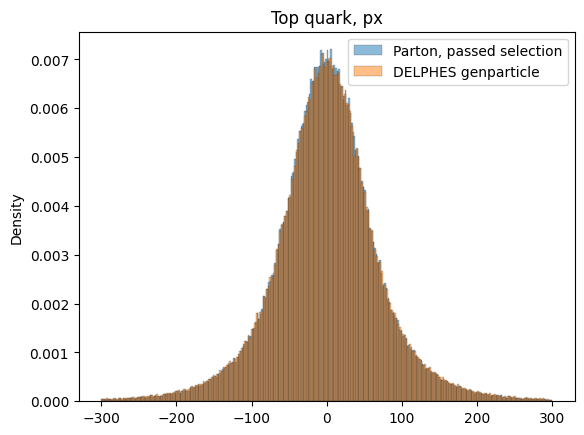

In [299]:
sns.histplot(p4top_passed.px, stat = 'density', label = "Parton, passed selection", alpha = .5, binrange = [-300,300])
sns.histplot(p4top_delp_gen.px, stat = 'density', label = "DELPHES genparticle", alpha = .5, binrange = [-300,300])
# sns.histplot(p4top_delp.px, stat = 'density', label = "DELPHES jet", alpha = .5, binrange = [-300,300])
plt.title('Top quark, px')
plt.legend()
plt.show()

In [300]:
boostedLepton_passed = p4Mu_passed.boostCM_of_p4(-p4top_passed).to_xyzt()
boostedLJet_passed = p4j2_passed.boostCM_of_p4(-p4top_passed).to_xyzt()
# Get the spatial components as 3D vectors
p3Lepton = boostedLepton_passed.to_Vector3D()
p3LJet = boostedLJet_passed.to_Vector3D()

# Calculate the cosine of the angle
Cos_lep_light_passed = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

In [301]:
boostedLepton_rejected = p4Mu_rejected.boostCM_of_p4(-p4top_rejected).to_xyzt()
boostedLJet_rejected = p4j2_rejected.boostCM_of_p4(-p4top_rejected).to_xyzt()
# Get the spatial components as 3D vectors
p3Lepton = boostedLepton_rejected.to_Vector3D()
p3LJet = boostedLJet_rejected.to_Vector3D()

# Calculate the cosine of the angle
Cos_lep_light_rejected = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

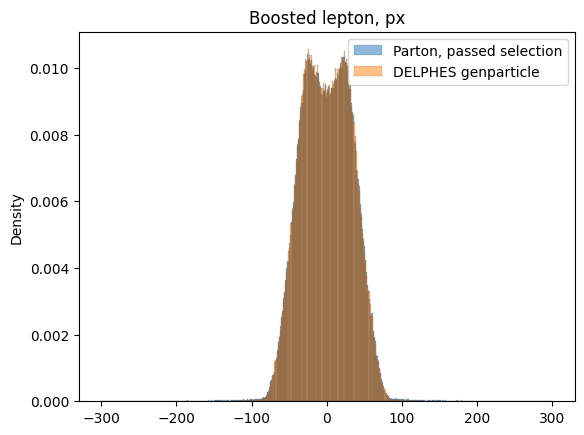

In [302]:
sns.histplot(boostedLepton_passed.px, stat = 'density', label = "Parton, passed selection", alpha = .5, binrange = [-300,300])
sns.histplot(boostedLepton_delp_gen.px, stat = 'density', label = "DELPHES genparticle", alpha = .5, binrange = [-300,300])
# sns.histplot(p4top_delp.px, stat = 'density', label = "DELPHES jet", alpha = .5, binrange = [-300,300])
plt.title('Boosted lepton, px')
plt.legend()
plt.show()

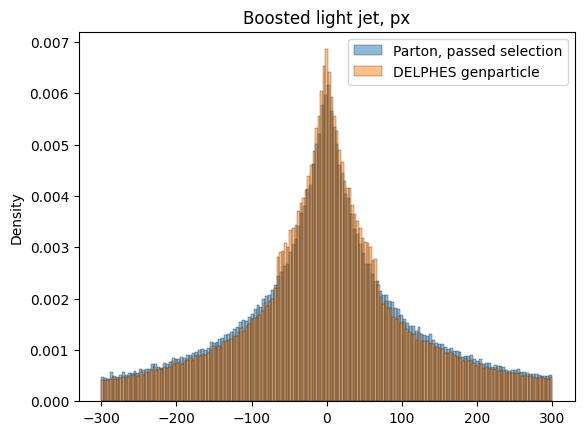

In [303]:
sns.histplot(boostedLJet_passed.px, stat = 'density', label = "Parton, passed selection", alpha = .5, binrange = [-300,300])
sns.histplot(boostedLJet_delp_gen.px, stat = 'density', label = "DELPHES genparticle", alpha = .5, binrange = [-300,300])
# sns.histplot(p4top_delp.px, stat = 'density', label = "DELPHES jet", alpha = .5, binrange = [-300,300])
plt.title('Boosted light jet, px')
plt.legend()
plt.show()

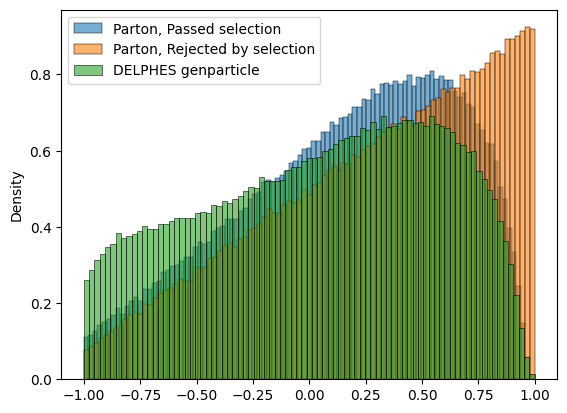

In [304]:
sns.histplot(Cos_lep_light_passed, stat = 'density', label = "Parton, Passed selection", alpha = .6)
sns.histplot(Cos_lep_light_rejected, stat = 'density', label = "Parton, Rejected by selection", alpha = .6)
sns.histplot(Cos_lep_light_delp_gen, stat = 'density', label = "DELPHES genparticle", alpha = .6)
# sns.histplot(Cos_lep_light_delp, stat = 'density', label = "DELPHES genparticle", alpha = .6)
plt.legend()
plt.show()

## Гибриды

In [305]:
p4W_hybr = p4Mu_delp_gen + p4nm_delp_gen
p4top_hybr = p4W_hybr + p4b1_passed
boostedLepton_hybr = p4Mu_delp_gen.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_passed.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

boostedLepton_hybr = p4Mu_delp_gen.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_delp_gen.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_j2 = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

p4top_hybr = p4W_hybr + p4b1_delp_gen
boostedLepton_hybr = p4Mu_delp_gen.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_passed.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_j1 = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

boostedLepton_hybr = p4Mu_delp_gen.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_delp_gen.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_j1j2 = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

In [306]:
p4W_hybr = p4Mu_delp + p4nm_delp_gen
p4top_hybr = p4W_hybr + p4b1_passed
boostedLepton_hybr = p4Mu_delp.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_passed.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_delp = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

boostedLepton_hybr = p4Mu_delp.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_delp.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_j2_delp = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

p4top_hybr = p4W_hybr + p4b1_delp
boostedLepton_hybr = p4Mu_delp.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_passed.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_j1_delp = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

boostedLepton_hybr = p4Mu_delp.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
boostedLJet_hybr = p4j2_delp.to_xyzt().boostCM_of_p4(-p4top_hybr.to_xyzt()).to_xyzt()
p3Lepton = boostedLepton_hybr.to_Vector3D()
p3LJet = boostedLJet_hybr.to_Vector3D()
Cos_lep_light_delp_hybr_j1j2_delp = p3Lepton.dot(p3LJet) / (p3Lepton.mag * p3LJet.mag)

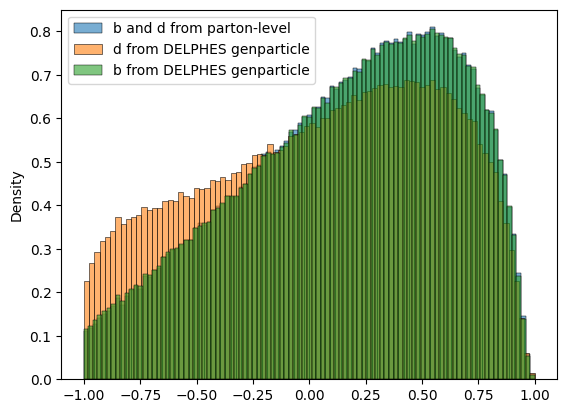

In [307]:
sns.histplot(Cos_lep_light_delp_hybr, stat = 'density', label = "b and d from parton-level", alpha = .6)
sns.histplot(Cos_lep_light_delp_hybr_j2, stat = 'density', label = "d from DELPHES genparticle", alpha = .6)
sns.histplot(Cos_lep_light_delp_hybr_j1, stat = 'density', label = "b from DELPHES genparticle", alpha = .6)
plt.legend()
plt.show()

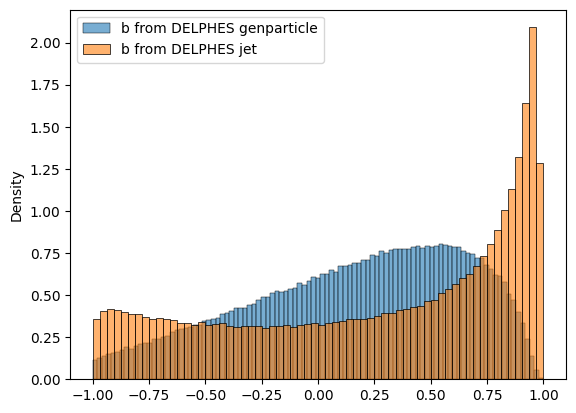

In [308]:
sns.histplot(Cos_lep_light_delp_hybr_j1, stat = 'density', label = "b from DELPHES genparticle", alpha = .6)
sns.histplot(Cos_lep_light_delp_hybr_j1_delp, stat = 'density', label = "b from DELPHES jet", alpha = .6)
plt.legend()
plt.show()

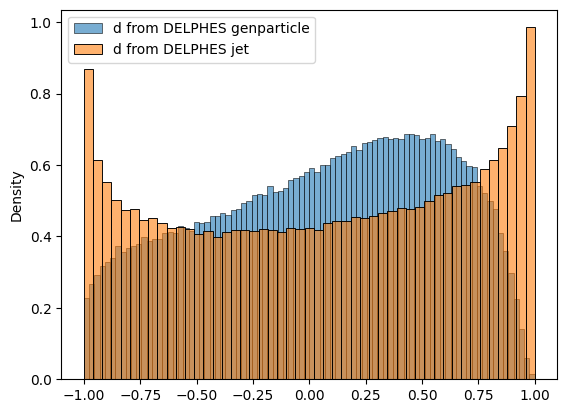

In [309]:
sns.histplot(Cos_lep_light_delp_hybr_j2, stat = 'density', label = "d from DELPHES genparticle", alpha = .6)
sns.histplot(Cos_lep_light_delp_hybr_j2_delp, stat = 'density', label = "d from DELPHES jet", alpha = .6)
plt.legend()
plt.show()

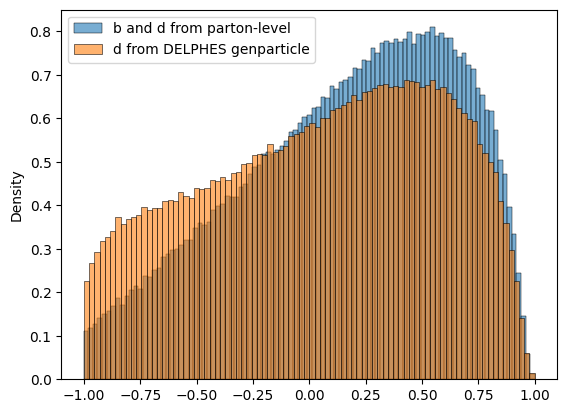

In [310]:
sns.histplot(Cos_lep_light_delp_hybr, stat = 'density', label = "b and d from parton-level", alpha = .6)
sns.histplot(Cos_lep_light_delp_hybr_j2, stat = 'density', label = "d from DELPHES genparticle", alpha = .6)
plt.legend()
plt.show()

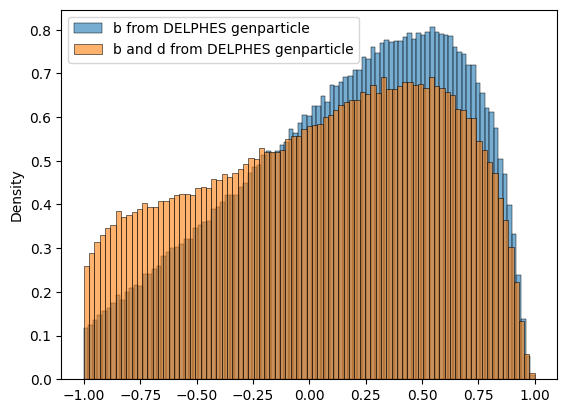

In [311]:
sns.histplot(Cos_lep_light_delp_hybr_j1, stat = 'density', label = "b from DELPHES genparticle", alpha = .6)
sns.histplot(Cos_lep_light_delp_hybr_j1j2, stat = 'density', label = "b and d from DELPHES genparticle", alpha = .6)
plt.legend()
plt.show()